# Data Generation

In [ ]:
# Clone CRAFT-pytorch
!git clone https://github.com/clovaai/CRAFT-pytorch.git

In [15]:
import warnings
warnings.filterwarnings("ignore")
import os
import shutil
from src.data_utils import *

In [16]:
def spatial_mapping_bboxes_to_transcript(bbox_path, transcript_path, output_path):
    """
    Map bounding boxes to transcript words using spatial ordering (top-left to bottom-right)
    instead of OCR-based matching. This is more accurate when we have ground truth data.
    """
    # Read transcript
    with open(transcript_path, 'r', encoding='utf-8') as f:
        transcript = f.read().strip()
    
    # Split transcript into words
    transcript_lines = transcript.split('\n')
    transcript_words = []
    for line in transcript_lines:
        transcript_words.extend(line.strip().split())
    
    # Read bounding boxes (in x1,y1,x2,y2 format)
    bounding_boxes = []
    with open(bbox_path, 'r') as f:
        for line in f.readlines():
            line = line.strip()
            if line:
                coords = [float(c) for c in line.split(',')]
                if len(coords) >= 4:
                    # For rectangular format x1,y1,x2,y2
                    x1, y1, x2, y2 = coords[:4]
                    
                    # Add padding to prevent cropping (especially on the right side)
                    padding_x = 4  # Horizontal padding
                    padding_y = 1  # Vertical padding
                    
                    x1_padded = x1 - padding_x
                    y1_padded = y1 - padding_y
                    x2_padded = x2 + padding_x
                    y2_padded = y2 + padding_y
                    
                    # Calculate center point for sorting (use original coordinates)
                    center_x = (x1 + x2) / 2
                    center_y = (y1 + y2) / 2
                    
                    # Convert to 8-coordinate format with padding
                    bbox_8coord = f"{x1_padded},{y1_padded},{x2_padded},{y1_padded},{x2_padded},{y2_padded},{x1_padded},{y2_padded}"
                    bounding_boxes.append({
                        'bbox': bbox_8coord,  # 8-coordinate format
                        'center_x': center_x,
                        'center_y': center_y,
                        'y1': y1  # Top coordinate for line grouping
                    })
    
    # Sort bounding boxes spatially (top-left to bottom-right)
    # First sort by Y coordinate (top to bottom), then by X coordinate (left to right)
    def spatial_sort_key(bbox):
        # Group by approximate line (using y1 with some tolerance)
        line_height_tolerance = 20  # Adjust based on your data
        line_group = int(bbox['y1'] / line_height_tolerance)
        return (line_group, bbox['center_x'])
    
    sorted_bboxes = sorted(bounding_boxes, key=spatial_sort_key)
    
    # Map words to bounding boxes in order
    mappings = []
    min_count = min(len(transcript_words), len(sorted_bboxes))
    
    for i in range(min_count):
        word = transcript_words[i]
        bbox = sorted_bboxes[i]['bbox']
        mappings.append((word, bbox))
    
    # Write results to output file
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    with open(output_path, 'w', encoding='utf-8') as f:
        for word, bbox in mappings:
            f.write(f"{word}\t{bbox}\n")
    
    return len(transcript_words), len(sorted_bboxes), len(mappings)


def spatial_mapping_all_files(image_dir, bbox_dir, transcript_dir, output_dir):
    """
    Apply spatial mapping to all files in the directories
    """
    os.makedirs(output_dir, exist_ok=True)
    
    # Get all image files
    image_files = [f for f in os.listdir(image_dir) 
                   if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    total_words = 0
    total_bboxes = 0
    total_mapped = 0
    
    print(f"Processing {len(image_files)} files...")
    
    for image_file in tqdm(image_files, desc="Spatial mapping"):
        # Get corresponding bbox and transcript files
        base_name = os.path.splitext(image_file)[0]
        bbox_file = base_name + '.txt'
        transcript_file = base_name + '.txt'
        
        bbox_path = os.path.join(bbox_dir, bbox_file)
        transcript_path = os.path.join(transcript_dir, transcript_file)
        # Output with _mapped.txt suffix as expected by extract_and_process_all_regions
        output_path = os.path.join(output_dir, base_name + '_mapped.txt')
        
        # Check if all files exist
        if os.path.exists(bbox_path) and os.path.exists(transcript_path):
            words, bboxes, mapped = spatial_mapping_bboxes_to_transcript(
                bbox_path, transcript_path, output_path)
            total_words += words
            total_bboxes += bboxes
            total_mapped += mapped
        else:
            print(f"Warning: Missing files for {base_name}")
    
    print(f"\n=== SPATIAL MAPPING SUMMARY ===")
    print(f"1. Total number of words in transcript files: {total_words}")
    print(f"2. Total number of bounding boxes detected: {total_bboxes}")
    print(f"3. Total number of image-word pairs successfully mapped: {total_mapped}")
    
    return total_words, total_bboxes, total_mapped


def adapted_data_generation_pipeline():
    """
    Adapted pipeline for images, bounding boxes, and transcripts that are already preprocessed (step 3)
    Uses spatial mapping instead of OCR-based mapping for better accuracy
    """
    
    # Step 3: Use existing data directories (no format conversion needed)
    image_dir = "OCR_data_synthetic/3_preprocessed/pages"
    bbox_dir = "OCR_data_synthetic/3_preprocessed/bboxes/words"  # Use original format directly
    transcript_dir = "OCR_data_synthetic/3_preprocessed/transcripts"

    # Step 4: Spatial mapping (instead of OCR-based mapping)
    print("Using spatial mapping for bounding boxes to transcripts...")
    total_words, total_bboxes, total_mapped = spatial_mapping_all_files(
        image_dir=image_dir,
        bbox_dir=bbox_dir,
        transcript_dir=transcript_dir,
        output_dir="OCR_data_synthetic/5_mapped"
    )

    print(f"Spatial mapping results: {total_words} words, {total_bboxes} bboxes, {total_mapped} mapped")

    # Step 5: Extract and process all regions to create word data
    df = extract_and_process_all_regions(
        image_root=image_dir,
        aligned_root="OCR_data_synthetic/5_mapped",
        output_root="OCR_data_synthetic/6_word_data/images",
        csv_output_path="OCR_data_synthetic/6_word_data/words.csv"
    )

    print(f"Extracted {len(df)} word images")

    # Step 6: Resize and pad images to a fixed size
    target_height, target_width = 128, 384

    resize_and_pad(
        input_dir="OCR_data_synthetic/6_word_data/images",
        output_dir="OCR_data_synthetic/final_dataset/images",
        target_height=target_height,
        target_width=target_width
    )

    print("Pipeline completed successfully!")


if __name__ == "__main__":
    # Run the adapted pipeline
    adapted_data_generation_pipeline()

Using spatial mapping for bounding boxes to transcripts...
Processing 289 files...


Spatial mapping: 100%|██████████| 289/289 [00:00<00:00, 351.07it/s]



=== SPATIAL MAPPING SUMMARY ===
1. Total number of words in transcript files: 69111
2. Total number of bounding boxes detected: 69111
3. Total number of image-word pairs successfully mapped: 69111
Spatial mapping results: 69111 words, 69111 bboxes, 69111 mapped


Creating Word Dataset: 100%|██████████| 289/289 [01:03<00:00,  4.59image/s]


Processed 69111 regions from 289 images
Images saved to: OCR_data_synthetic/6_word_data/images
CSV saved to: OCR_data_synthetic/6_word_data/words.csv
Extracted 69111 word images


Resizing and Padding Images: 100%|██████████| 69111/69111 [20:29<00:00, 56.22img/s]  

Pipeline completed successfully!


In [8]:
def data_generation_pipeline():
    
    # 1. Split books and transcripts into individual files
    process_books_with_transcripts(
        input_books_folder="OCR_data_original/1_raw/books/",
        input_transcripts_folder="OCR_data_original/1_raw/transcripts/",
        output_books_folder="OCR_data_original/2_splitted/books/",
        output_transcripts_folder="OCR_data_original/2_splitted/transcripts/"
    )

    # 2. Preprocessing images
    copy_all_transcripts()
    # copy_all_images()

    book_transformations = {
        'book1': {
            'denoise_image': {'method': 'bilateral'},
            'denoise_image': {'method': 'nlm'}
        },
        'book2': {
            'ensure_300ppi': {'target_dpi': 150},
            'remove_bleed_dual_layer': {},
            'denoise_image': {'method': 'bilateral'},
            'denoise_image': {'method': 'nlm'},
            'denoise_image': {'method': 'nlm'}
        },
        'book3': {
            'ensure_300ppi': {'target_dpi': 300},
            'remove_bleed_dual_layer': {},
            'denoise_image': {'method': 'bilateral'}
            },
        'book4': {
            'ensure_300ppi': {'target_dpi': 300},
            'remove_bleed_dual_layer': {},
            'denoise_image': {'method': 'bilateral'}
        },
        'book5': {
            'ensure_300ppi': {'target_dpi': 300}
        },
        'book6': {
            'ensure_300ppi': {'target_dpi': 300},
            'remove_bleed_dual_layer': {},
            'denoise_image': {'method': 'bilateral'}
        },
        'book7': {
            'remove_bleed_dual_layer': {},
            'denoise_image': {'method': 'nlm'},
            'denoise_image': {'method': 'bilateral'}
        },
        'book8': {
            'remove_bleed_dual_layer': {},
            'denoise_image': {'method': 'nlm'},
            'denoise_image': {'method': 'bilateral'}
        },
        'book9': {
            'ensure_300ppi': {'target_dpi': 300},
            'remove_bleed_dual_layer': {},
            'denoise_image': {'method': 'wiener'},
            'sharpen_image': {'method': 'laplacian'}
        },
        'book10': {
            'ensure_300ppi': {'target_dpi': 300},
            'remove_bleed_dual_layer': {},
            'denoise_image': {'method': 'wiener'},
            'sharpen_image': {'method': 'laplacian'}
        },
        'book11': {
            'ensure_300ppi': {'target_dpi': 300},
            'remove_bleed_dual_layer': {},
            'denoise_image': {'method': 'bilateral'},
        },
        'book12': {
            'ensure_300ppi': {'target_dpi': 300},
            'remove_bleed_dual_layer': {},
            'denoise_image': {'method': 'bilateral'},
            'sharpen_image': {'method': 'laplacian'},
        },
    }

    stats = process_multiple_books(
        books_base_dir="OCR_data_original/2_splitted/books", 
        output_dir="OCR_data_original/3_processed/books",
        book_transformations=book_transformations
    )
    
    # 3. Generate bounding boxes for each book page
    input_root = "OCR_data_original/3_processed/books"
    output_root = "OCR_data_original/4_bounding_boxes//"
    model_path = "CRAFT-pytorch/weights/craft_mlt_25k.pth"

    text_detection(
        input_root=input_root,
        output_root=output_root,
        model_path=model_path
    )

    plot_random_pages(
        images_dir="OCR_data_original/3_processed/books",
        bbox_dir="OCR_data_original/4_bounding_boxes",
        save_dir="assets/plots/"
    )
    
    # 4. Mapping bounding boxes to transcripts
    # This function will map the bounding boxes generated in the previous step to the corresponding words in the transcripts.
    similarity_threshold = 0.8
    
    total_words, total_bboxes, total_mapped = mapping_bounding_boxes(
        image_dir="OCR_data_original/3_processed/books",
        bbox_dir="OCR_data_original/4_bounding_boxes", 
        transcript_dir="OCR_data_original/3_processed/transcripts",
        output_dir="OCR_data_original/5_mapped",
        tesseract_model=1,
        similarity_threshold=0.8
    )

    # 5. Extract and process all regions to create word data
    # This will extract words from the mapped bounding boxes and save them in the specified output directory.
    df = extract_and_process_all_regions(
        image_root = "OCR_data_original/3_processed/books",
        aligned_root = "OCR_data_original/5_mapped",
        output_root = "OCR_data_original/6_word_data/images",
        csv_output_path = "OCR_data_original/6_word_data/words.csv"
    )
        
    # 6. Resize and pad images to a fixed size

    target_height, target_width = 128,384

    resize_and_pad(
        input_dir="OCR_data_original/6_word_data/images",
        output_dir="OCR_data_original/final_dataset/images",
        target_height=target_height,
        target_width=target_width
    )

    
if __name__ == "__main__":        
        data_generation_pipeline()

Processing 98 files...


Mapping bounding boxes: 100%|██████████| 98/98 [1:01:52<00:00, 37.89s/file]



=== MAPPING SUMMARY ===
1. Total number of words in transcript files: 17528
2. Total number of bounding boxes detected: 18010
3. Total number of image-word pairs successfully mapped: 11239


Creating Word Dataset: 100%|██████████| 98/98 [01:18<00:00,  1.25image/s]


Processed 11239 regions from 98 images
Images saved to: OCR_data_original/6_word_data/images
CSV saved to: OCR_data_original/6_word_data/words.csv


Resizing and Padding Images: 100%|██████████| 11239/11239 [05:58<00:00, 31.39img/s]


In [17]:
import pandas as pd
df = pd.read_csv('OCR_data_synthetic/6_word_data/words.csv')
df['Image'] = df['Image'].apply(lambda x: os.path.join('OCR_data_synthetic/final_dataset/images', x))
df.to_csv('OCR_data_synthetic/6_word_data/words.csv', index=False)

In [ ]:
# import pandas as pd
# df = pd.read_csv('OCR_data_original/6_word_data/words.csv')
# df['Image'] = df['Image'].apply(lambda x: os.path.join('OCR_data_original/final_dataset/images', x))
# df.to_csv('OCR_data_original/6_word_data/words.csv', index=False)

# OCR Model

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import pandas as pd
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
import cv2
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import os
from torch.optim.lr_scheduler import ReduceLROnPlateau
import pandas as pd
import time
import unicodedata
from sklearn.model_selection import train_test_split

In [2]:
df1 = pd.read_csv('OCR_data_synthetic/6_word_data/words.csv')
df2 = pd.read_csv('OCR_data_original/6_word_data/words.csv')
df = pd.concat([df1, df2], ignore_index=True)
df2, val_df = train_test_split(df2, test_size=0.2, random_state=42)

## Both real and synthetic data
train_df = pd.concat([df1[['Image','label']], df2[['Image','label']]], ignore_index=True)
# Only real data
# train_df = df2[['Image','label']]
BATCH_SIZE = 64
train_df = train_df[['Image', 'label']]
val_df = val_df[['Image', 'label']]

labels = [str(word) for word in df['label'].to_numpy()]

# Unique characters
unique_chars = set(char for word in labels for char in word)
n_classes = len(unique_chars)

# Show
print(f"Total number of unique characters before : {n_classes}")
print(f"Unique Characters : \n{unique_chars}")

# Define character normalization function
def normalize_char(c):
    # Rule 1: Convert uppercase to lowercase
    c = c.lower()
    
    # Rule 2: Handle u and v interchangeably (choosing u as standard)
    if c == 'v':
        c = 'u'
    
    # Rule 3: Handle different types of 's'
    if c == 'ſ':  # Long s
        c = 's'
    
    # Rule 4: Ignore accents except ñ
    if c not in ['ñ']:
        # Decompose the character and keep only the base letter
        normalized = ''.join(char for char in unicodedata.normalize('NFD', c) 
                            if not unicodedata.combining(char))
        c = normalized
    
    # Rule 7: Replace ç with z
    if c == 'ç':
        c = 'z'
    
    return c

# Normalize labels
def normalize_text(text):
    return ''.join(normalize_char(c) for c in str(text))

# Get normalized labels
normalized_labels = [normalize_text(word) for word in df['label'].to_numpy()]

# Extract unique characters after normalization
unique_chars = set(char for word in normalized_labels for char in word)
n_classes = len(unique_chars)

# Show normalized character set# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Character mapping with normalized characters
characters = sorted(list(unique_chars))
char_to_idx = {c: i+1 for i, c in enumerate(characters)}  # Start index from 1 (0 reserved for blank)
char_to_idx['<blank>'] = 0  # Blank character
idx_to_char = {i+1: c for i, c in enumerate(characters)}
idx_to_char[0] = '<blank>'  # Blank character

NUM_CLASSES = len(characters) + 1  # Extra for blank

# Also update the training and validation DataFrames with normalized labels
train_df['normalized_label'] = train_df['label'].apply(normalize_text)
val_df['normalized_label'] = val_df['label'].apply(normalize_text)

print(f"Character to index mapping: {char_to_idx}")
print(f"Number of classes (including blank): {NUM_CLASSES}") 
print(f"Total number of unique characters after normalization: {n_classes}")
print(f"Normalized unique characters: \n{unique_chars}")

Total number of unique characters before : 97
Unique Characters : 
{'°', 'ü', 'v', 'a', 'G', '1', 'L', ')', 'é', 'k', '&', '.', '-', '"', 'Y', 'C', 'y', 'Ñ', 'V', '!', 'Á', 'R', 'F', 'º', '¿', "'", 'ó', 'U', 'c', 'è', 'l', '0', 'î', 'm', 'q', 'g', 'ú', '?', ';', 'H', 's', '8', 'O', 'M', 'I', '¡', 'X', 'N', 'P', 'Z', '6', 'S', '7', 'A', 'z', 'í', '4', 'T', '2', 'ô', '(', 'K', 'w', '»', ':', 'ç', 'u', '3', 'É', 'Q', 'o', '5', 'x', 'ª', 'D', 'n', 'ñ', 'j', 't', 'p', 'h', 'E', ',', 'b', 'B', 'á', 'r', '«', 'J', '[', 'Í', 'f', 'd', '9', 'e', 'i', 'Ó'}
Using device: cuda
Character to index mapping: {'!': 1, '"': 2, '&': 3, "'": 4, '(': 5, ')': 6, ',': 7, '-': 8, '.': 9, '0': 10, '1': 11, '2': 12, '3': 13, '4': 14, '5': 15, '6': 16, '7': 17, '8': 18, '9': 19, ':': 20, ';': 21, '?': 22, '[': 23, 'a': 24, 'b': 25, 'c': 26, 'd': 27, 'e': 28, 'f': 29, 'g': 30, 'h': 31, 'i': 32, 'j': 33, 'k': 34, 'l': 35, 'm': 36, 'n': 37, 'o': 38, 'p': 39, 'q': 40, 'r': 41, 's': 42, 't': 43, 'u': 44, 'w': 45, 'x'

In [3]:
import torch
from torch.utils.data import Dataset
import cv2
import numpy as np
import os

class OCRDataset(Dataset):
    def __init__(self, dataframe, char_to_idx, idx_to_char, height=128, cmap = 'gray'):

        self.dataframe = dataframe
        self.height = height
        
        self.char_to_idx = char_to_idx
        self.idx_to_char = idx_to_char
        self.cmap = cmap
        
        
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
        
        # Get image path and label
        img_path = self.dataframe.iloc[idx, 0]
        label = self.dataframe.iloc[idx, 2]  ## 1:label , 2: Normalized_label
        
        # Check if image path exists
        if not os.path.exists(img_path):
            print(f"Warning: Image not found: {img_path}")
            # Return a dummy white image if file doesn't exist
            image = np.ones((self.height, 100), dtype=np.uint8) * 255
        else:
            if self.cmap == 'gray':
                image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            elif self.cmap == 'rgb':
                image = cv2.imread(img_path)
                if image is not None:
                    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            
            # Check if image was loaded successfully
            if image is None:
                print(f"Warning: Could not read image: {img_path}")
                # Return a dummy white image if loading failed
                image = np.ones((self.height, 100), dtype=np.uint8) * 255
        
        # Store original dimensions
        if len(image.shape) == 3:  # RGB image (height, width, channels)
            original_height, original_width, _ = image.shape
        else:  # Grayscale image (height, width)
            original_height, original_width = image.shape
        
        # Resize to fixed height while maintaining aspect ratio
        aspect_ratio = original_width / original_height
        new_width = int(aspect_ratio * self.height)
        image = cv2.resize(image, (new_width, self.height))
        
        # Convert to tensor and normalize
        if self.cmap =="gray":
            image_tensor = torch.from_numpy(image).float().unsqueeze(0) / 255.0
        elif self.cmap == "rgb":
            image_tensor = torch.from_numpy(image).float().permute(2, 0, 1) / 255.0
        
        # Convert label to indices
        label_indices = [self.char_to_idx[c] for c in label]
        label_tensor = torch.tensor(label_indices, dtype=torch.long)
        
        return {
            'image': image_tensor,
            'label': label_tensor,
            'width': new_width,
            'text': label
        }
    
    def get_vocab_size(self):
        return len(self.char_to_idx)

In [4]:
import torch
import torch.nn.functional as F

def collate_fn(batch):

    # Extract items
    images = [item['image'] for item in batch]
    labels = [item['label'] for item in batch]
    widths = [item['width'] for item in batch]
    texts = [item['text'] for item in batch]
    
    # Find max width in the batch
    max_width = max(widths)
    batch_size = len(images)
    
    # Pad images to max width in the batch (not globally)
    padded_images = []
    for image in images:
        _, h, w = image.size()
        padding_size = max_width - w
        if padding_size > 0:
            # Pad the width dimension to match max_width
            padded_image = F.pad(image, (0, padding_size, 0, 0), "constant", 0)
        else:
            padded_image = image
        padded_images.append(padded_image)
    
    # Stack images to form a batch
    images_tensor = torch.stack(padded_images)
    
    # Find max label length in the batch
    max_label_len = max([len(label) for label in labels])
    
    # Pad labels to max length
    padded_labels = []
    label_lengths = []
    for label in labels:
        label_lengths.append(len(label))
        # Pad with zeros (index for blank)
        if len(label) < max_label_len:
            padded_label = torch.cat([
                label, 
                torch.zeros(max_label_len - len(label), dtype=torch.long)
            ])
        else:
            padded_label = label
        padded_labels.append(padded_label)
    
    # Convert to tensors
    padded_labels = torch.stack(padded_labels)
    label_lengths = torch.tensor(label_lengths, dtype=torch.long)
    widths = torch.tensor(widths, dtype=torch.long)
    
    return {
        'images': images_tensor,
        'labels': padded_labels,
        'label_lengths': label_lengths,
        'widths': widths,
        'texts': texts
    }

In [5]:
### DataLoaders

'''
Note that the image height defines how many dimensions will be passed to the LSTM layer after being processed by the CNN.
So if I change the heigth I will also require to change the LSTM input size accordingly.(the code is static for now)
'''
train_dataset = OCRDataset(train_df,char_to_idx, idx_to_char, height=128,cmap='gray')
val_dataset = OCRDataset(val_df, char_to_idx, idx_to_char, height=128,cmap='gray')

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    collate_fn=collate_fn,
    pin_memory=True
)
val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    collate_fn=collate_fn,
    pin_memory=True
)

In [6]:
class CRNN(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.2, cmap='gray'):
        super(CRNN, self).__init__()
        
        # Enhanced CNN Feature Extractor
        in_channels = 1 if cmap == 'gray' else 3
        
        # First block
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv1_2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn1_2 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)  # 128 -> 64 , W->w/2
        
        # Second block
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv2_2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn2_2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)  # 64 -> 32 , w/2 -> w/4
        
        # Third block
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv3_2 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn3_2 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)  # 32 -> 16, w/4 -> w/8
        
        # Fourth block
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.conv4_2 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.bn4_2 = nn.BatchNorm2d(256)
        self.pool4 = nn.MaxPool2d(2, 2)  # 16 -> 8, w/8 -> w/16
        
        # Regularization
        self.dropout_cnn = nn.Dropout(dropout_rate)
        self.dropout_lstm = nn.Dropout(dropout_rate + 0.1) 
        
        # Calculate final feature map dimensions after CNN
        feature_size = 256 * 8
        
        # Multi-layer LSTM
        self.lstm1 = nn.LSTM(feature_size, 256, bidirectional=True, batch_first=True)  # 512 = 256*2(256 hidden units in each direction)
        self.lstm2 = nn.LSTM(512, 256, bidirectional=True, batch_first=True)
        
        # Output Layer with attention mechanism
        self.attention = nn.Linear(512, 1)
        self.fc = nn.Linear(512, num_classes)
    
    def forward(self, x):
        # First CNN block with residual-like connection
        x1 = nn.functional.relu(self.bn1(self.conv1(x)))
        x1 = nn.functional.relu(self.bn1_2(self.conv1_2(x1)))
        x = self.pool1(x1)
        
        # Second CNN block
        x2 = nn.functional.relu(self.bn2(self.conv2(x)))
        x2 = nn.functional.relu(self.bn2_2(self.conv2_2(x2)))
        x = self.pool2(x2)
        
        # Third CNN block
        x3 = nn.functional.relu(self.bn3(self.conv3(x)))
        x3 = nn.functional.relu(self.bn3_2(self.conv3_2(x3)))
        x = self.pool3(x3)
        
        # Fourth CNN block
        x4 = nn.functional.relu(self.bn4(self.conv4(x)))
        x4 = nn.functional.relu(self.bn4_2(self.conv4_2(x4)))
        x = self.pool4(x4)
        
        x = self.dropout_cnn(x)
        '''
        Reshape for LSTM: (batch, channels, height, width) -> (batch, width, channels*height)
        w/16 is the number of timesteps (from the width dimension)
        Each timestep has 256*(8) features
        '''
        b, c, h, w = x.shape
        x = x.permute(0, 3, 1, 2).contiguous().view(b, w, c*h)   
        
        # Stacked LSTM layers
        x, _ = self.lstm1(x)
        x = self.dropout_lstm(x)   ### Output from LSTM1: (batch_size, w/16, 512)
        x, _ = self.lstm2(x)
        x = self.dropout_lstm(x)   ### Output from LSTM2: (batch_size, w/16, 512)

        
        ##  Simple attention mechanism
        ## a linear layer that transforms each timestep's features (512-dimensional) into a single scalar value
        ## so self.attention(x) produces (batch_size, w/16, 1) ---squeeze ---> (batch_size, w/16)
        ## then we apply softmax to get the probabilities for each timestep
        ## unsqueeze(2) adds a dimension: (batch_size, w/16, 1)
        ## expand_as(x) broadcasts this to match the LSTM output shape: (batch_size, w/16, 512)
        
        attn_weights = torch.softmax(self.attention(x).squeeze(-1), dim=1)    
        attn_weights = attn_weights.unsqueeze(2).expand_as(x)
        
        x = x * attn_weights  # Multiply each feature by its attention weight
        
        # Apply attention and classification
        x = self.fc(x)
        
        return x  # (batch, seq_len, num_classes)

In [8]:
# Decode predictions (greedy decoding)
def decode_predictions(predictions):
    # Simple greedy decoding
    decoded_preds = []
    for pred in predictions:
        collapsed = []
        prev_char = -1
        for p in pred:
            if p != prev_char:  # CTC collapse
                collapsed.append(p)
            prev_char = p
        
        # Remove blank tokens (0)
        result = [idx_to_char[c] for c in collapsed if c > 0]
        decoded_preds.append(''.join(result))
    
    return decoded_preds

# Creating a custom CER function
def calculate_cer(pred_texts, true_texts):
    total_distance = 0
    total_length = 0
    
    for pred, true in zip(pred_texts, true_texts):
        # Calculate Levenshtein distance
        distance = levenshtein_distance(pred, true)
        total_distance += distance
        total_length += len(true)
    
    return total_distance / total_length if total_length > 0 else 1.0

# Levenshtein distance implementation
def levenshtein_distance(s1, s2):
    if len(s1) < len(s2):
        return levenshtein_distance(s2, s1)
    
    if len(s2) == 0:
        return len(s1)
    
    previous_row = range(len(s2) + 1)
    for i, c1 in enumerate(s1):
        current_row = [i + 1]
        for j, c2 in enumerate(s2):
            insertions = previous_row[j + 1] + 1
            deletions = current_row[j] + 1
            substitutions = previous_row[j] + (c1 != c2)
            current_row.append(min(insertions, deletions, substitutions))
        previous_row = current_row
    
    return previous_row[-1]

In [9]:
def validate(model, val_loader, criterion):
    model.eval()
    val_loss = 0
    all_pred_texts = []
    all_true_texts = []
    correct_count = 0
    total_count = 0
    
    with torch.no_grad():
        for batch in val_loader:
            # Get batch data
            images = batch['images'].to(device)
            labels = batch['labels'].to(device)
            label_lengths = batch['label_lengths'].to(device)
            texts = batch['texts']  # Original text labels
            
            # Forward pass
            outputs = model(images).log_softmax(2)
            outputs_for_loss = outputs.permute(1, 0, 2)  # (T, N, C)
            
            # Calculate loss
            input_lengths = torch.full((outputs.size(0),), outputs.size(1), dtype=torch.long, device=device)
            
            # Calculate loss
            loss = criterion(outputs_for_loss, labels, input_lengths, label_lengths)
            val_loss += loss.item()
            
            # Get predictions
            predictions = outputs.argmax(2).detach().cpu().numpy()
            pred_texts = decode_predictions(predictions)
            
            # Calculate accuracy
            for pred, true in zip(pred_texts, texts):
                total_count += 1
                if pred == true:
                    correct_count += 1
            
            all_pred_texts.extend(pred_texts)
            all_true_texts.extend(texts)
    
    # Calculate metrics
    avg_val_loss = val_loss / len(val_loader)
    accuracy = correct_count / total_count if total_count > 0 else 0
    cer = calculate_cer(all_pred_texts, all_true_texts)
    
    return avg_val_loss, cer, accuracy, all_pred_texts, all_true_texts

In [10]:
import os
import pandas as pd
import torch
from tqdm import tqdm

def train(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs, patience, min_delta, checkpoint_dir='OCR_models/', resume=False):
    os.makedirs(checkpoint_dir, exist_ok=True)
    
    # Path for checkpoint and history files
    checkpoint_path = os.path.join(checkpoint_dir, 'latest_checkpoint.pth')
    best_model_path = os.path.join(checkpoint_dir, 'best_model.pth')
    history_path = os.path.join(checkpoint_dir, 'training_history.csv')
    
    # Initialize training state variables
    start_epoch = 0
    best_val_loss = float('inf')
    counter = 0
    best_epoch = 0
    
    # Initialize or load history
    if resume and os.path.exists(history_path):
        # Load existing history
        history_df = pd.read_csv(history_path)
        history = {
            'train_loss': history_df['train_loss'].tolist(),
            'val_loss': history_df['val_loss'].tolist(),
            'val_cer': history_df['val_cer'].tolist(),
            'val_accuracy': history_df['val_accuracy'].tolist(),
            'learning_rates': history_df['learning_rates'].tolist()
        }
        print(f"Loaded training history from {history_path}")
    else:
        # Initialize new history
        history = {
            'train_loss': [],
            'val_loss': [],
            'val_cer': [],
            'val_accuracy': [],
            'learning_rates': []
        }
    
    # Resume training if requested and checkpoint exists
    if resume and os.path.exists(checkpoint_path):
        print(f"Resuming training from {checkpoint_path}")
        checkpoint = torch.load(checkpoint_path)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        start_epoch = checkpoint['epoch']
        best_val_loss = checkpoint['best_val_loss']
        counter = checkpoint['counter']
        best_epoch = checkpoint['best_epoch']
        print(f"Resuming from epoch {start_epoch}/{num_epochs}")
    
    for epoch in range(start_epoch, num_epochs):
        model.train()
        train_loss = 0.0
        train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')
        
        for batch_idx, batch in enumerate(train_pbar):
            images = batch['images'].to(device)
            labels = batch['labels'].to(device)
            label_lengths = batch['label_lengths'].to(device)
            
            outputs = model(images).log_softmax(2)
            outputs_for_loss = outputs.permute(1, 0, 2)
            input_lengths = torch.full((outputs.size(0),), outputs.size(1), dtype=torch.long, device=device)
            
            loss = criterion(outputs_for_loss, labels, input_lengths, label_lengths)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            train_pbar.set_postfix({'loss': loss.item()})
        
        avg_train_loss = train_loss / len(train_loader)
        
        # Validate
        avg_val_loss, cer, accuracy, all_pred_texts, all_true_texts = validate(model, val_loader, criterion)
        scheduler.step(avg_val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        
        # Update history
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_cer'].append(cer)
        history['val_accuracy'].append(accuracy)
        history['learning_rates'].append(current_lr)
        
        # Save history as CSV after each epoch
        history_df = pd.DataFrame(history)
        history_df.to_csv(history_path, index=False)
        
        # Print epoch stats
        print(f"\nEpoch {epoch+1}/{num_epochs}:")
        print(f"Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")
        print(f"Accuracy: {accuracy:.4f}, CER: {cer:.4f}, LR: {current_lr:.6f}")
        
        # Save checkpoint after each epoch
        torch.save({
            'epoch': epoch + 1,  # Save the next epoch to start from
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_val_loss': best_val_loss,
            'counter': counter,
            'best_epoch': best_epoch,
        }, checkpoint_path)
        
        # Early stopping logic and save best model
        if avg_val_loss < best_val_loss - min_delta:
            best_val_loss = avg_val_loss
            counter = 0
            best_epoch = epoch + 1
            
            # Save best model (based on validation loss)
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'cer': cer,
                'accuracy': accuracy,
                'val_loss': avg_val_loss
            }, best_model_path)
            
            print(f"Saved best model with val_loss: {best_val_loss:.4f}")
        else:
            counter += 1
            
            if counter >= patience:
                print(f"Early stopping triggered after {epoch+1} epochs")
                break
    
    # Load the best model weights (based on validation loss)
    best_checkpoint = torch.load(best_model_path)
    model.load_state_dict(best_checkpoint['model_state_dict'])
    final_cer = best_checkpoint['cer']
    final_accuracy = best_checkpoint['accuracy']
    best_epoch = best_checkpoint['epoch']
    
    print(f"\nTraining completed. Restored best model from epoch {best_epoch}")
    print(f"Final CER: {final_cer:.4f}, Final Accuracy: {final_accuracy:.4f}")
    
    return history

In [ ]:
model = CRNN(NUM_CLASSES,cmap='gray').to(device)

criterion = nn.CTCLoss(blank=0, reduction="mean", zero_infinity=True)
optimizer = optim.Adam(
    model.parameters(), 
    lr=0.001, 
    weight_decay=1e-4
)
scheduler = ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5,
    patience=8
)

In [ ]:
# Set hyperparameters
NUM_EPOCHS = 500
PATIENCE = 20
MIN_DELTA = 0.0001
CHECKPOINT_DIR = 'OCR_models/Real_and_synthetic/'

# Train the model
history = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
    min_delta=MIN_DELTA,
    checkpoint_dir= CHECKPOINT_DIR,
    # resume = True
)


Epoch 1/500: 100%|██████████| 1221/1221 [10:01<00:00,  2.03it/s, loss=2.43]



Epoch 1/500:
Train Loss: 4.2694, Val Loss: 2.6956
Accuracy: 0.0018, CER: 0.8799, LR: 0.001000
Saved best model with val_loss: 2.6956


Epoch 2/500: 100%|██████████| 1221/1221 [09:12<00:00,  2.21it/s, loss=0.466]



Epoch 2/500:
Train Loss: 1.0843, Val Loss: 0.6984
Accuracy: 0.5827, CER: 0.1738, LR: 0.001000
Saved best model with val_loss: 0.6984


Epoch 3/500: 100%|██████████| 1221/1221 [08:44<00:00,  2.33it/s, loss=0.0863]


...


Epoch 67/500:
Train Loss: 0.0274, Val Loss: 0.1536
Accuracy: 0.9137, CER: 0.0248, LR: 0.000031


Epoch 68/500: 100%|██████████| 1221/1221 [08:31<00:00,  2.39it/s, loss=0.00731]



Epoch 68/500:
Train Loss: 0.0256, Val Loss: 0.1518
Accuracy: 0.9177, CER: 0.0240, LR: 0.000031


Epoch 69/500: 100%|██████████| 1221/1221 [08:29<00:00,  2.40it/s, loss=0.00854]



Epoch 69/500:
Train Loss: 0.0254, Val Loss: 0.1567
Accuracy: 0.9168, CER: 0.0243, LR: 0.000031
Early stopping triggered after 69 epochs

Training completed. Restored best model from epoch 49
Final CER: 0.0258, Final Accuracy: 0.9150


Sample accuracy: 0.8500 (17/20)


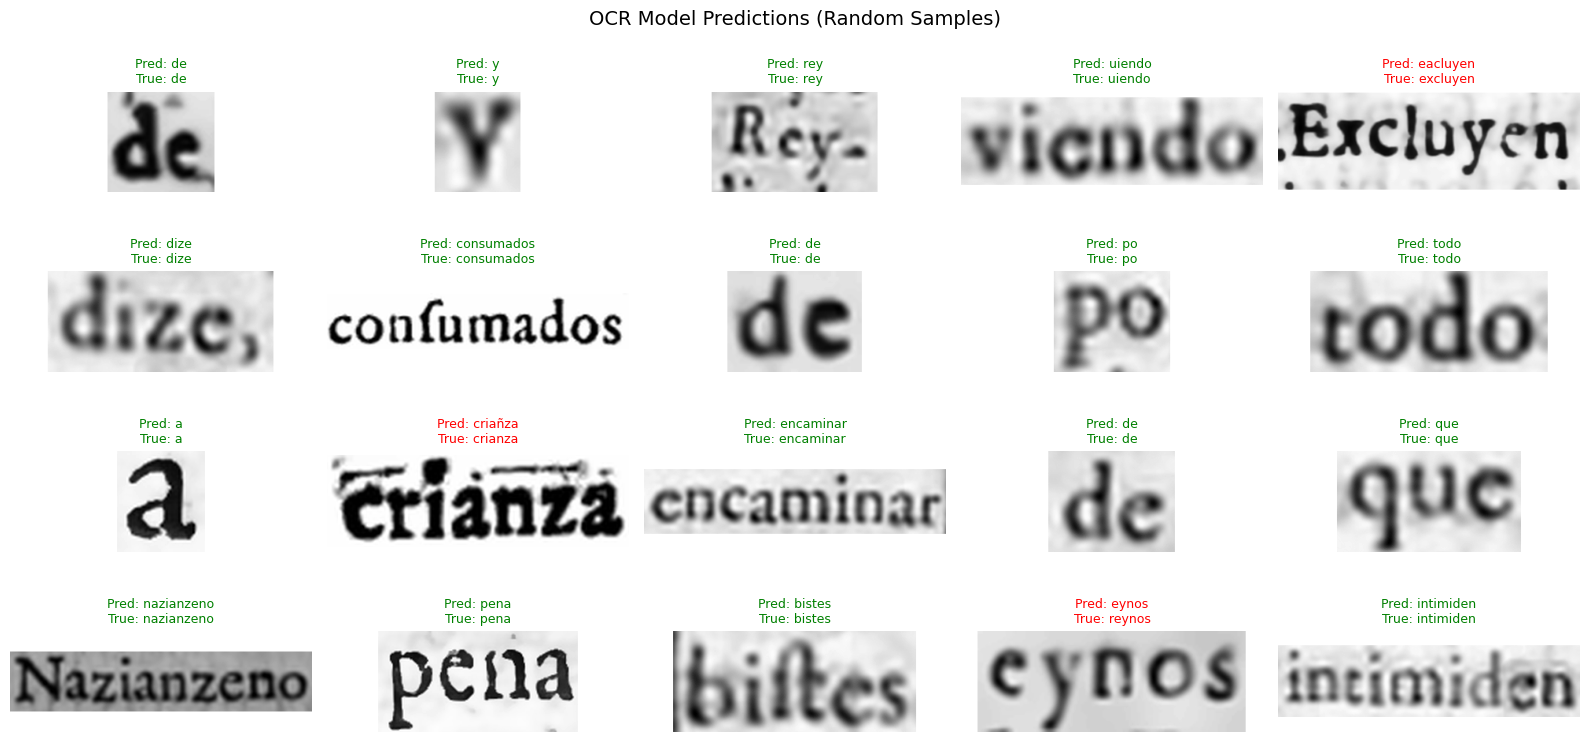

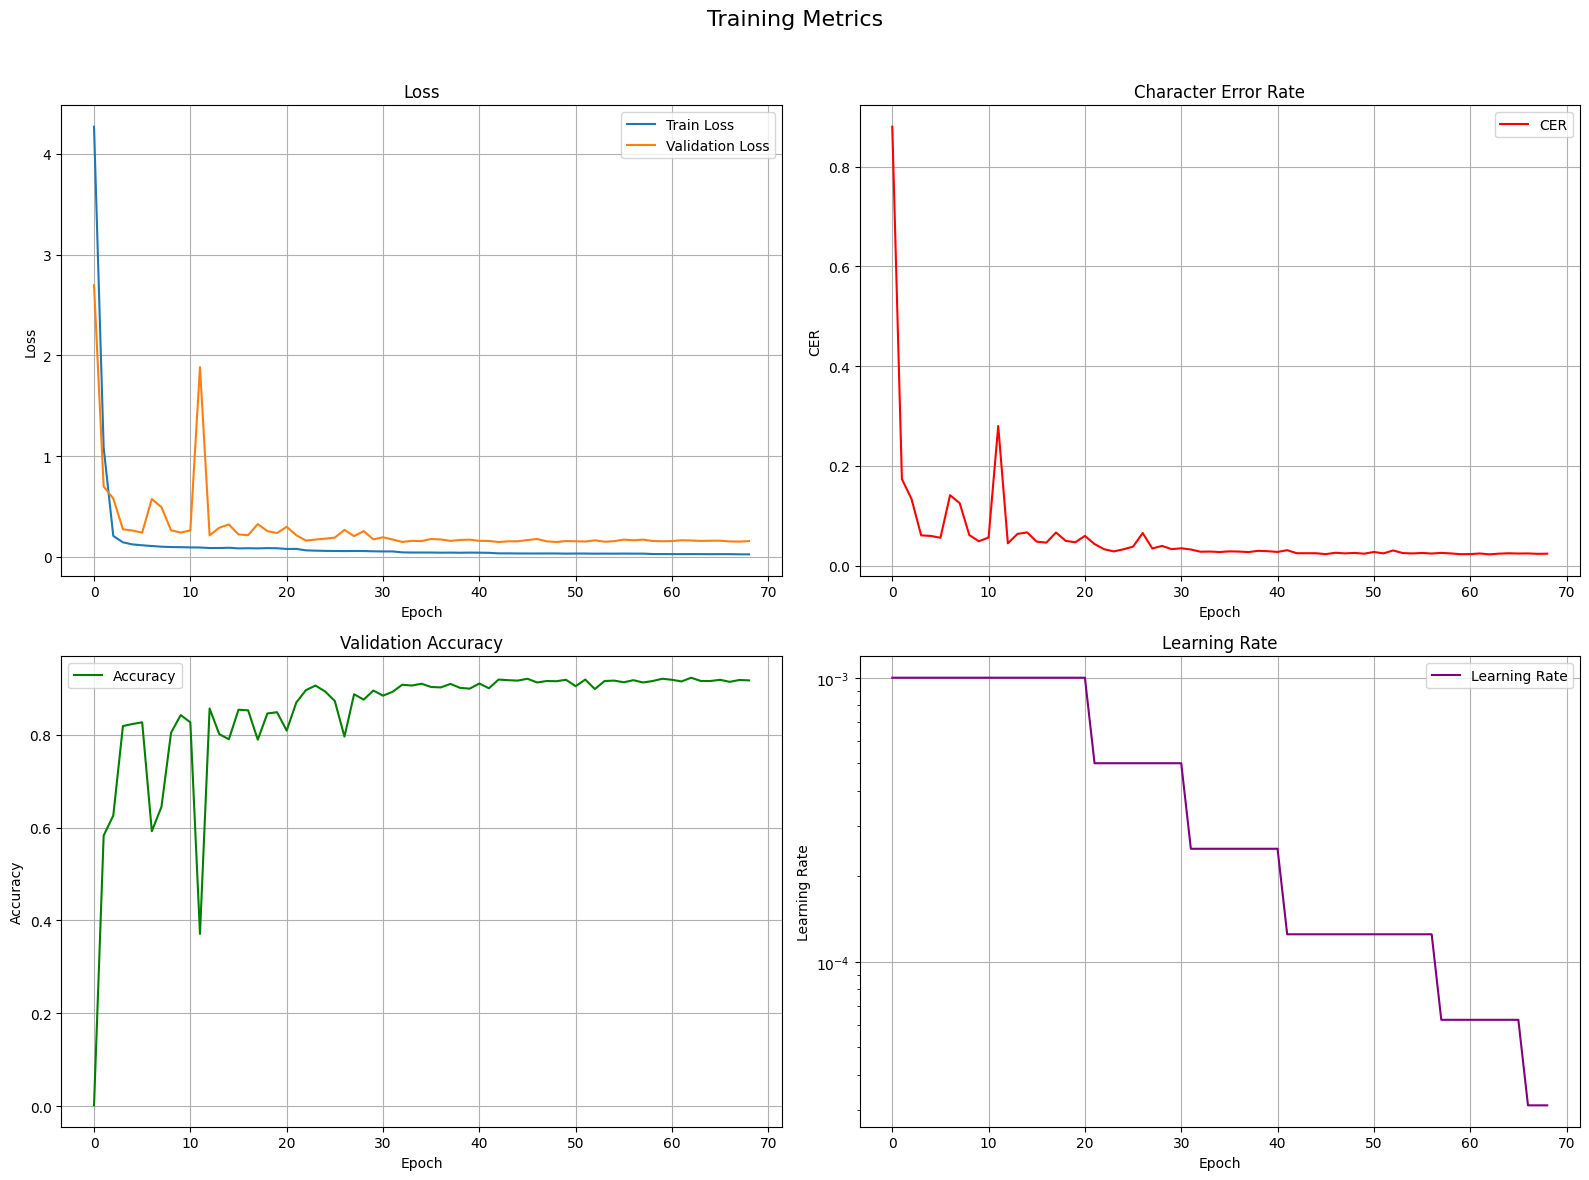

In [14]:
trained_model = CRNN(NUM_CLASSES, cmap='gray').to(device)
trained_model.load_state_dict(torch.load(f'{CHECKPOINT_DIR}/best_model.pth')['model_state_dict'])
history_df = pd.read_csv(f'{CHECKPOINT_DIR}/training_history.csv')


def plot_training_metrics(history):
    # Create a figure with subplots
    fig, axs = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Training Metrics', fontsize=16)
    
    # Plot Training and Validation Loss
    axs[0, 0].plot(history['train_loss'], label='Train Loss')
    axs[0, 0].plot(history['val_loss'], label='Validation Loss')
    axs[0, 0].set_title('Loss')
    axs[0, 0].set_xlabel('Epoch')
    axs[0, 0].set_ylabel('Loss')
    axs[0, 0].legend()
    axs[0, 0].grid(True)
    
    # Plot Character Error Rate (CER)
    axs[0, 1].plot(history['val_cer'], label='CER', color='red')
    axs[0, 1].set_title('Character Error Rate')
    axs[0, 1].set_xlabel('Epoch')
    axs[0, 1].set_ylabel('CER')
    axs[0, 1].legend()
    axs[0, 1].grid(True)
    
    # Plot Accuracy
    axs[1, 0].plot(history['val_accuracy'], label='Accuracy', color='green')
    axs[1, 0].set_title('Validation Accuracy')
    axs[1, 0].set_xlabel('Epoch')
    axs[1, 0].set_ylabel('Accuracy')
    axs[1, 0].legend()
    axs[1, 0].grid(True)
    
    # Plot Learning Rate
    axs[1, 1].plot(history['learning_rates'], label='Learning Rate', color='purple')
    axs[1, 1].set_title('Learning Rate')
    axs[1, 1].set_xlabel('Epoch')
    axs[1, 1].set_ylabel('Learning Rate')
    axs[1, 1].set_yscale('log')  # Log scale for better visualization
    axs[1, 1].legend()
    axs[1, 1].grid(True)
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to make room for the title
    plt.savefig(f'{CHECKPOINT_DIR}/training_metrics.png', dpi=300, bbox_inches='tight')
    plt.show()

def predict_and_visualize_random(model, data_loader, idx_to_char, device, num_samples=10, save_path=None, seed=None):
    import random
    import numpy as np
    import torch.nn.functional as F
    
    # Set random seed for reproducibility if provided
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
    
    model.eval()
    
    # Get all samples from the loader
    all_data = []
    for batch in data_loader:
        batch_size = len(batch['texts'])
        for i in range(batch_size):
            item = {
                'image': batch['images'][i],
                'text': batch['texts'][i]
            }
            all_data.append(item)
            
            # Break if we already have enough samples
            if len(all_data) >= num_samples * 10:  # Get 10x more than needed to have a good random selection
                break
        
        if len(all_data) >= num_samples * 10:
            break
    
    # Select random samples
    num_samples = min(num_samples, len(all_data))
    random_indices = random.sample(range(len(all_data)), num_samples)
    selected_samples = [all_data[i] for i in random_indices]
    
    # Process each image individually
    predictions = []
    texts = [sample['text'] for sample in selected_samples]
    images_for_display = [sample['image'].clone() for sample in selected_samples]  # Clone to avoid modifying originals
    
    # Get predictions one by one to avoid padding issues
    correct_count = 0
    total_count = 0
    
    with torch.no_grad():
        for i, sample in enumerate(selected_samples):
            # Process single image
            image = sample['image'].unsqueeze(0).to(device)  # Add batch dimension
            output = model(image).log_softmax(2)
            prediction = output.argmax(2).cpu().numpy()[0]  # Get first (only) item from batch
            
            # Decode prediction
            decoded_pred = decode_single_prediction(prediction, idx_to_char)
            predictions.append(decoded_pred)
            
            # Check if prediction is correct
            if decoded_pred == sample['text']:
                correct_count += 1
            total_count += 1
    
    accuracy = correct_count / total_count
    print(f"Sample accuracy: {accuracy:.4f} ({correct_count}/{total_count})")
    
    # Display samples
    rows = (num_samples + 4) // 5  # Ensure 5 samples per row
    fig, axs = plt.subplots(rows, 5, figsize=(16, 2 * rows))
    
    # Handle the case when rows=1
    if rows == 1:
        axs = np.array([axs]).reshape(1, -1)
    
    axs = axs.flatten()
    
    for i in range(num_samples):
        # Get the image and convert to numpy for display
        image = images_for_display[i].cpu().numpy()
        
        # Handle different channel dimensions for display
        if image.shape[0] == 1:  # Grayscale
            image = image.squeeze(0)  # Remove channel dimension for grayscale
            axs[i].imshow(image, cmap="gray")
        else:  # RGB
            # Move channels to the end for visualization
            image = np.transpose(image, (1, 2, 0))
            axs[i].imshow(image)
        
        # Color code the title based on whether prediction is correct
        title_color = 'green' if predictions[i] == texts[i] else 'red'
        
        axs[i].set_title(f"Pred: {predictions[i]}\nTrue: {texts[i]}", 
                         fontsize=9, color=title_color)
        axs[i].axis("off")
    
    # Hide unused subplots
    for i in range(len(axs)):
        if i >= num_samples:
            axs[i].axis("off")
    
    plt.suptitle("OCR Model Predictions (Random Samples)", fontsize=14)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
    
    plt.show()

def decode_single_prediction(prediction, idx_to_char):
    # Remove repeated characters
    collapsed = []
    prev_char = -1
    for p in prediction:
        if p != prev_char:  # CTC collapse
            collapsed.append(p)
        prev_char = p
    
    # Remove blank tokens (0)
    result = [idx_to_char[c] for c in collapsed if c > 0]
    return ''.join(result)

# Function to determine the number of channels in an image tensor
def get_num_channels(img_tensor):
    return img_tensor.shape[0]

# Function to convert between RGB and grayscale if needed
def ensure_image_format(img_tensor, target_channels):
    current_channels = img_tensor.shape[0]
    
    # Already in the right format
    if current_channels == target_channels:
        return img_tensor
    
    # Convert RGB to grayscale
    if current_channels == 3 and target_channels == 1:
        # RGB to grayscale conversion weights
        weights = torch.tensor([0.2989, 0.5870, 0.1140], device=img_tensor.device)
        return (img_tensor * weights.view(3, 1, 1)).sum(dim=0, keepdim=True)
    
    # Convert grayscale to RGB
    if current_channels == 1 and target_channels == 3:
        return img_tensor.repeat(3, 1, 1)
    
    raise ValueError(f"Unsupported conversion: {current_channels} to {target_channels} channels")

# Example usage with automatic format handling:
predict_and_visualize_random(
    model=trained_model,
    data_loader=val_loader,
    idx_to_char=idx_to_char,
    device=device,
    num_samples=20,
    save_path= f'{CHECKPOINT_DIR}/predictions.png',
    seed=2  # For reproducible results
)

# After training the model and having the history dictionary
plot_training_metrics(history)